In [8]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go up one level so 'blocks' is visible

In [18]:
# DoWhy Playground - See Full Causal Inference Power
from blocks.draw import draw_duplo_dag_inline
from blocks.sample_dags import sample_dag, m_bias_dag
from blocks.simulate import simulate_data
from blocks.regression import causal_regression
from blocks.dowhy import estimate_effect
from blocks.plot import plot_regression, correlation_heatmap
import pandas as pd
import numpy as np
import dowhy.datasets
from dowhy import CausalModel

In [19]:
# Set seed to enable exact replication
np.random.seed(1)

# Simulate sample data
data = dowhy.datasets.linear_dataset(
    beta=1,
    num_common_causes=2,
    num_discrete_common_causes=1,
    num_instruments=1,
    num_samples=10000,
    treatment_is_binary=True)

df = data['df']

In [20]:
# Create a causal model from the data and given graph.
model=CausalModel(
        data = df,
        treatment=data['treatment_name'],
        outcome=data['outcome_name'],
        graph=data['gml_graph']
        )

In [21]:
# Run a linear regression of column y on v0 in df
import statsmodels.api as sm

X = df['v0'].astype(float)
y = df['y'].astype(float)

X = sm.add_constant(X)

ols = sm.OLS(y, X).fit()

# Display a more parsimonious results summary
print(ols.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7966      0.017     47.194      0.000       0.764       0.830
v0             1.2947      0.022     59.804      0.000       1.252       1.337



🎯 SCENARIO 1: Classic Confounding
Structure: Z → X, Z → Y (Z is confounder)


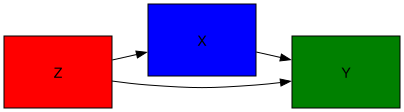


Data preview:
          Z         X         Y
0  0.496714  1.896070  1.717605
1 -0.138264  0.786369  0.503586
2  0.647689  0.707319  0.562588
3  1.523030  0.876093  2.091161
4 -0.234153  0.464070 -1.663698

Regression Results:
Naive (no controls): 1.4959
Proper (control Z): 0.9898

DoWhy Results:
DoWhy naive: 1.4959
DoWhy proper: 0.9898


/Users/george/Desktop/programming/projects/causal_duplo/causal_env/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/george/Desktop/programming/projects/causal_duplo/causal_env/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


In [15]:
# ===== Scenario 1: Proper Confounding (DoWhy Should Work) =====
print("\n🎯 SCENARIO 1: Classic Confounding")
print("Structure: Z → X, Z → Y (Z is confounder)")

confounder_dag = sample_dag()
draw_duplo_dag_inline(confounder_dag)

# Simulate and analyze
data1 = simulate_data(confounder_dag, n=1000, seed=42)
print("\nData preview:")
print(data1[['Z', 'X', 'Y']].head())

# Regression comparison
model1_naive = causal_regression(data1, x="X", y="Y", controls=[])
model1_proper = causal_regression(data1, x="X", y="Y", controls=["Z"])

print(f"\nRegression Results:")
print(f"Naive (no controls): {model1_naive.params['X']:.4f}")
print(f"Proper (control Z): {model1_proper.params['X']:.4f}")

# DoWhy analysis: try/except when DoWhy's causal reasoning potentially disagrees with your approach
print(f"\nDoWhy Results:")
try:
    effect1_naive = estimate_effect(data1, x="X", y="Y", controls=[])
    print(f"DoWhy naive: {effect1_naive.value:.4f}")
except Exception as e:
    print(f"DoWhy naive: Failed - {str(e)[:50]}...")

try:
    effect1_proper = estimate_effect(data1, x="X", y="Y", controls=["Z"])
    print(f"DoWhy proper: {effect1_proper.value:.4f}")
except Exception as e:
    print(f"DoWhy proper: Failed - {str(e)[:50]}...")





🚫 SCENARIO 2: M-bias (Collider)
Structure: U1 → X,M  U2 → M,Y (M is collider)


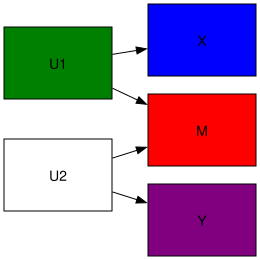


Regression Results:
Correct (no M): -0.0232
Wrong (control M): -0.2045

DoWhy Results:
DoWhy correct: -0.0232
DoWhy wrong: -0.2045
⚠️  DoWhy computed result but M is a collider!


/Users/george/Desktop/programming/projects/causal_duplo/causal_env/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/george/Desktop/programming/projects/causal_duplo/causal_env/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


In [11]:
# ===== Scenario 2: M-bias (DoWhy Should Detect Problem) =====
print("\n\n🚫 SCENARIO 2: M-bias (Collider)")
print("Structure: U1 → X,M  U2 → M,Y (M is collider)")

mbias_dag = m_bias_dag()
draw_duplo_dag_inline(mbias_dag)

data2 = simulate_data(mbias_dag, n=1000, seed=42)

# Regression comparison
model2_correct = causal_regression(data2, x="X", y="Y", controls=[])
model2_wrong = causal_regression(data2, x="X", y="Y", controls=["M"])

print(f"\nRegression Results:")
print(f"Correct (no M): {model2_correct.params['X']:.4f}")
print(f"Wrong (control M): {model2_wrong.params['X']:.4f}")

# DoWhy analysis
print(f"\nDoWhy Results:")
try:
    effect2_correct = estimate_effect(data2, x="X", y="Y", controls=[])
    print(f"DoWhy correct: {effect2_correct.value:.4f}")
except Exception as e:
    print(f"DoWhy correct: Failed - {str(e)[:50]}...")

try:
    effect2_wrong = estimate_effect(data2, x="X", y="Y", controls=["M"])
    print(f"DoWhy wrong: {effect2_wrong.value:.4f}")
    print("⚠️  DoWhy computed result but M is a collider!")
except Exception as e:
    print(f"DoWhy wrong: Failed - {str(e)[:50]}...")
    print("✅ DoWhy detected the problem and refused!")



✨ SCENARIO 3: No Confounding
Structure: X → Y (direct causal effect only)


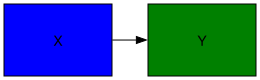


Regression Result: 0.9588
DoWhy Result: 0.9588
✅ Perfect agreement - no confounding needed!


/Users/george/Desktop/programming/projects/causal_duplo/causal_env/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


In [12]:
# ===== Scenario 3: No Confounding (Simple Case) =====
print("\n\n✨ SCENARIO 3: No Confounding")
print("Structure: X → Y (direct causal effect only)")

simple_dag = [
    {"name": "X", "color": "blue", "targets": ["Y"]},
    {"name": "Y", "color": "green", "targets": []}
]
draw_duplo_dag_inline(simple_dag)

data3 = simulate_data(simple_dag, n=1000, seed=42)

# Regression
model3 = causal_regression(data3, x="X", y="Y", controls=[])
print(f"\nRegression Result: {model3.params['X']:.4f}")

# DoWhy
try:
    effect3 = estimate_effect(data3, x="X", y="Y", controls=[])
    print(f"DoWhy Result: {effect3.value:.4f}")
    print("✅ Perfect agreement - no confounding needed!")
except Exception as e:
    print(f"DoWhy failed: {str(e)[:50]}...")

